# Analyse multidimensionnelle des trajectoires de soins pour le jeu de données `multidimensional_data`

Ce notebook présente l'application du package `trajectoryclusteringanalysis` sur un jeu de données de traitements d'un cancer exprimé en mois.

1. Configuration de l'environnement et imports
2. Chargement et préparation des données
3. Initialisation du modèle TCA et construction du tenseur
4. Décomposition par l'algorithme SWoTTeD
5. Clustering sur les intensités des phénotypes

## 1. Imports

In [1]:
from pathlib import Path
import sys
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import torch
import random
import matplotlib.patches as mpatches


project_root = None
for base in [Path.cwd(), *Path.cwd().parents]:
    src_candidate = base / "src" / "trajectoryclusteringanalysis"
    if src_candidate.exists():
        project_root = base
        break

if project_root is None:
    raise FileNotFoundError(
        f"Could not find project root containing src/trajectoryclusteringanalysis from {Path.cwd()}"
    )

src_path = project_root / "src"
if str(src_path) not in sys.path:
    sys.path.insert(0, str(src_path))

from trajectoryclusteringanalysis import TCA
from trajectoryclusteringanalysis.plotting import *

print(f"Using local package from: {src_path}")

from trajectoryclusteringanalysis.tca import TCA

Using local package from: c:\Users\imen.miloudi\OneDrive - Aix-Marseille Université\Documents\stage\TrajectoryClusteringAnalysis\src


## 2. Chargement et préparation des données

In [2]:
df = pd.read_csv(project_root / "data" / "multidimensional_data.csv")
df

,PATIENT_ID,EVENT,TIME
0,1,Chirurgie,0
1,1,Chimiothérapie IV,1
2,1,Chimiothérapie IV,1
3,1,Chimiothérapie IV,2
4,1,Chimiothérapie IV,3
...,...,...,...
20430,1336,Chimiothérapie IV,2
20431,1336,Chimiothérapie IV,2
20432,1336,Chimiothérapie IV,3
20433,1336,Chimiothérapie IV,3


In [3]:
from sklearn.preprocessing import LabelEncoder

label_encoder = LabelEncoder()
timed_event_structure = df.copy()

timed_event_structure['Event'] = label_encoder.fit_transform(timed_event_structure['EVENT'])
timed_event_structure.drop(columns=['EVENT'], inplace=True)
timed_event_structure.columns = ['ID_PATIENT', 'Time', 'Event']
noms_events = label_encoder.classes_
timed_event_structure

,ID_PATIENT,Time,Event
0,1,0,2
1,1,1,0
2,1,1,0
3,1,2,0
4,1,3,0
...,...,...,...
20430,1336,2,0
20431,1336,2,0
20432,1336,3,0
20433,1336,3,0


In [4]:
nunique = timed_event_structure['ID_PATIENT'].nunique()
print(f"Number of unique patients: {nunique}")

Number of unique patients: 1336


In [5]:
# Get the set of all unique Event values
unique_events = timed_event_structure['Event'].unique()
all_events = set(unique_events)

# Find patients who have all occurrences of Event
patients_with_all_events = timed_event_structure.groupby('ID_PATIENT').filter(
    lambda group: set(group['Event']) == all_events
)['ID_PATIENT'].unique()

print(f"Patients with all occurrences of Event: {len(patients_with_all_events)}")
print(patients_with_all_events)

Patients with all occurrences of Event: 50
[   8   23   45   65   66  134  157  173  176  178  188  194  220  228
  242  275  312  343  361  390  428  466  469  472  478  537  544  546
  575  613  665  673  688  759  775  790  792  831  845  867  895  937
  943  969  984 1081 1126 1286 1293 1333]


## 3. Initialisation du modèle TCA

In [6]:
# Créer une instance de TCA pour l'analyse multidimensionnelle
tca = TCA(data=timed_event_structure,
              index_col='ID_PATIENT',
              time_col='Time', 
              event_col='Event',
              mode='multidimensional',
              )

INFO:root:TCA object initialized successfully
INFO:root:The multidimensional analysis mode is set. TCA object will analyze the data accordingly.


Dataset :
data shape:  (20435, 3)
state coding:
    label  label encoded
0      0              0
1      1              1
2      2              2
3      3              3


In [7]:
tca.analyzer.transform_time_event_structure_to_tensor()
print("Tensor shape:", tca.analyzer.get_tensor_shape())
tensor = tca.analyzer.get_tensor()

Tensor shape: torch.Size([1336, 4, 24])


Patient utilise pour la visualisation: 23


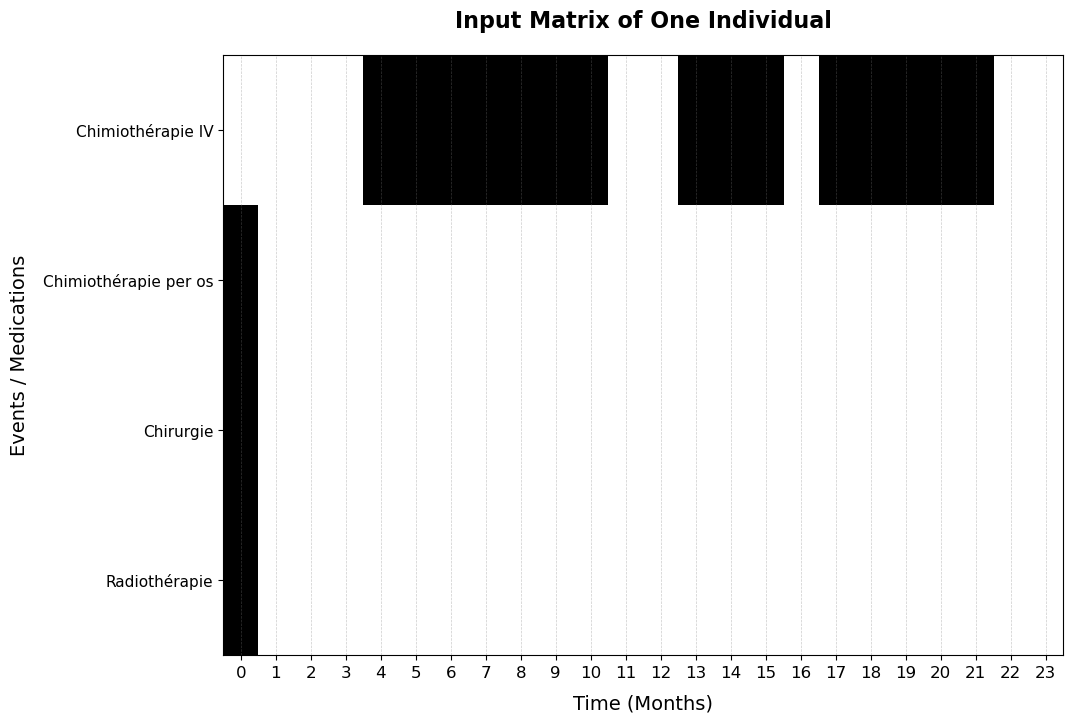

     PATIENT_ID                  EVENT  TIME
561          23              Chirurgie     0
562          23  Chimiothérapie per os     0
563          23          Radiothérapie     0
564          23          Radiothérapie     0
565          23          Radiothérapie     0
566          23          Radiothérapie     0
567          23      Chimiothérapie IV     4
568          23      Chimiothérapie IV     5
569          23      Chimiothérapie IV     5
570          23      Chimiothérapie IV     6
571          23      Chimiothérapie IV     7
572          23      Chimiothérapie IV     7
573          23      Chimiothérapie IV     8
574          23      Chimiothérapie IV     8
575          23      Chimiothérapie IV     9
576          23      Chimiothérapie IV    10
577          23      Chimiothérapie IV    13
578          23      Chimiothérapie IV    13
579          23      Chimiothérapie IV    14
580          23      Chimiothérapie IV    15
581          23      Chimiothérapie IV    17
582       

In [8]:
patient_index = int(patients_with_all_events[1])
print(f"Patient utilise pour la visualisation: {patient_index}")

plot_input_matrix(tensor, id=patient_index, labels=noms_events, time_unit='Months')

print(df[df['PATIENT_ID'] == 23])

## 4. Décomposition du jeu de données à l'aide de l'algorithme SWOTTED

In [11]:
# Hyperparametres de la demo
metric = 'Bernoulli'
learning_rate = 1e-2
n_epochs = 200  # 30 pour demo rapide, 100+ pour entrainement plus stable

In [ ]:
ranks = [2, 3, 4, 5]
windows = [2, 3, 4]
#sparsities = [0.1, 0.3, 0.5, 0.7, 0.9]
sparsities = [0.5, 0.7, 0.9]
non_successions = [0.1, 0.3, 0.5, 0.7, 0.9]
models = {}

# Nombre max de tests
n_essais_max = 10


for i in range(n_essais_max):
    r = random.choice(ranks)
    w = random.choice(windows)
    s = random.choice(sparsities)
    ns = random.choice(non_successions)
    
    print(f"\n--- Essai {i+1}/{n_essais_max} : R={r}, W={w}, S={s}, NS={ns} ---")
    
    tca.analyzer.fit_swotted_decomposition(
        tensor, rank=r, time_window_length=w, 
        reg_term_ns=ns, reg_term_s=s, metric=metric, 
        learning_rate=learning_rate, n_epochs=n_epochs, fit_metric_every_n_epochs=0 
    )

    models[(r, w, s, ns)] = (tca.analyzer.model, tca.analyzer.W)

GPU available: False, used: False
TPU available: False, using: 0 TPU cores
💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.
💡 Tip: For seamless cloud uploads and versioning, try installing [litmodels](https://pypi.org/project/litmodels/) to enable LitModelCheckpoint, which syncs automatically with the Lightning model registry.

  | Name         | Type          | Params | Mode  | FLOPs
---------------------------------------------------------------
0 | model        | SlidingWindow | 0      | train | 0    
  | other params | n/a           | 24     | n/a   | n/a  
---------------------------------------------------------------
24        Trainable params
0         Non-trainable params
24        Total params
0.000     Total estimated model params size (MB)
1         Modules in train mode
0         Modules in eval


--- Essai 1/10 : R=2, W=3, S=0.9, NS=0.9 ---


Training: |          | 0/? [00:00<?, ?it/s]

Epoch 1/200 - train_loss: 16.225500
Epoch 2/200 - train_loss: 15.869534
Epoch 3/200 - train_loss: 15.393966
Epoch 4/200 - train_loss: 16.896538
Epoch 5/200 - train_loss: 15.600214
Epoch 6/200 - train_loss: 15.558577
Epoch 7/200 - train_loss: 15.677206
Epoch 8/200 - train_loss: 15.236799
Epoch 9/200 - train_loss: 16.628235
Epoch 10/200 - train_loss: 15.290473
Epoch 11/200 - train_loss: 15.280882
Epoch 12/200 - train_loss: 15.472748
Epoch 13/200 - train_loss: 15.290630
Epoch 14/200 - train_loss: 15.067041
Epoch 15/200 - train_loss: 15.507318
Epoch 16/200 - train_loss: 14.842824
Epoch 17/200 - train_loss: 16.119207
Epoch 18/200 - train_loss: 14.667443
Epoch 19/200 - train_loss: 14.740248
Epoch 20/200 - train_loss: 14.570833
Epoch 21/200 - train_loss: 19.640951
Epoch 22/200 - train_loss: 16.550587
Epoch 23/200 - train_loss: 14.556092
Epoch 24/200 - train_loss: 14.501581
Epoch 25/200 - train_loss: 14.488161


GPU available: False, used: False
TPU available: False, using: 0 TPU cores
💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.
💡 Tip: For seamless cloud uploads and versioning, try installing [litmodels](https://pypi.org/project/litmodels/) to enable LitModelCheckpoint, which syncs automatically with the Lightning model registry.

  | Name         | Type          | Params | Mode  | FLOPs
---------------------------------------------------------------
0 | model        | SlidingWindow | 0      | train | 0    
  | other params | n/a           | 48     | n/a   | n/a  
---------------------------------------------------------------
48        Trainable params
0         Non-trainable params
48        Total params
0.000     Total estimated model params size (MB)
1         Modules in train mode
0         Modules in eval

Training: |          | 0/? [00:00<?, ?it/s]

Epoch 1/300 - train_loss: 16.596106
Epoch 2/300 - train_loss: 15.082995
Epoch 3/300 - train_loss: 15.160623
Epoch 4/300 - train_loss: 15.194077
Epoch 5/300 - train_loss: 15.234388
Epoch 6/300 - train_loss: 15.265115
Epoch 7/300 - train_loss: 15.277488
Epoch 8/300 - train_loss: 15.333899
Epoch 9/300 - train_loss: 15.337113
Epoch 10/300 - train_loss: 17.302404
Epoch 11/300 - train_loss: 15.434956
Epoch 12/300 - train_loss: 15.330653
Epoch 13/300 - train_loss: 15.487465
Epoch 14/300 - train_loss: 21.932636
Epoch 15/300 - train_loss: 16.596148
Epoch 16/300 - train_loss: 15.678864
Epoch 17/300 - train_loss: 18.237068
Epoch 18/300 - train_loss: 15.285754
Epoch 19/300 - train_loss: 38.694046
Epoch 20/300 - train_loss: 29.415285
Epoch 21/300 - train_loss: 26.157148
Epoch 22/300 - train_loss: 38.195351
Epoch 23/300 - train_loss: 35.061890
Epoch 24/300 - train_loss: 31.115700
Epoch 25/300 - train_loss: 27.443007
Epoch 26/300 - train_loss: 24.232384
Epoch 27/300 - train_loss: 21.270361
Epoch 28/3

`Trainer.fit` stopped: `max_epochs=300` reached.


Decomposed into 1336 pathways with rank 4 and time window length 3
Success rate for the entire dataset: -2.4874


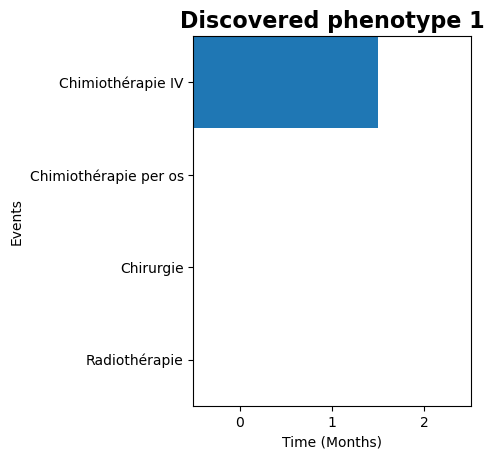

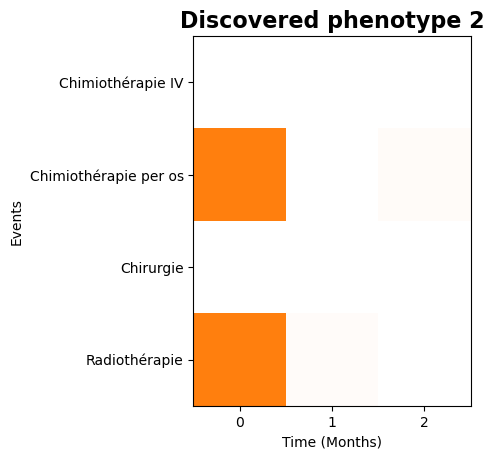

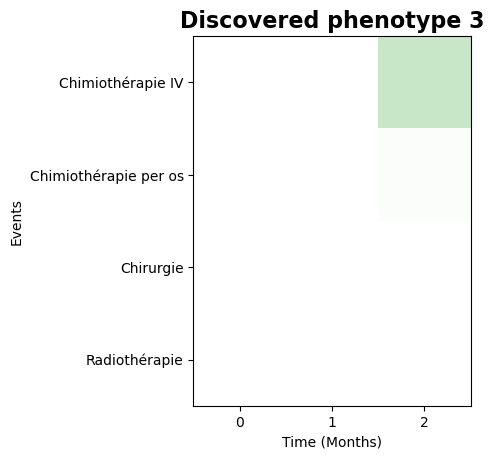

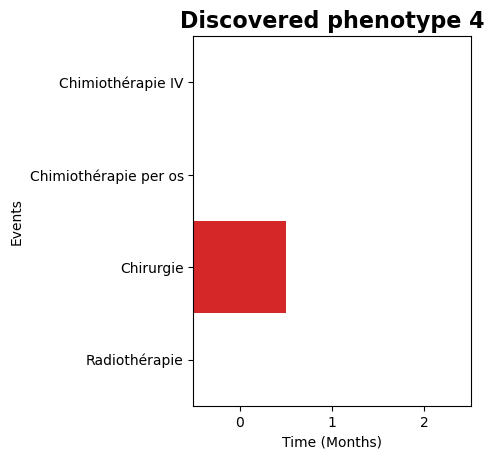

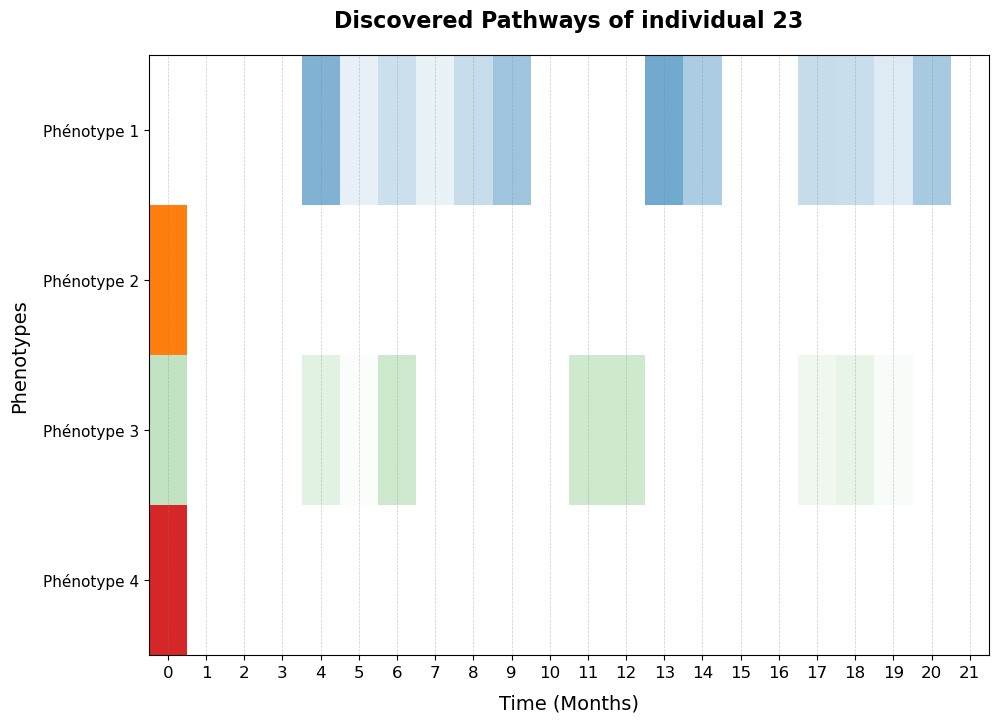

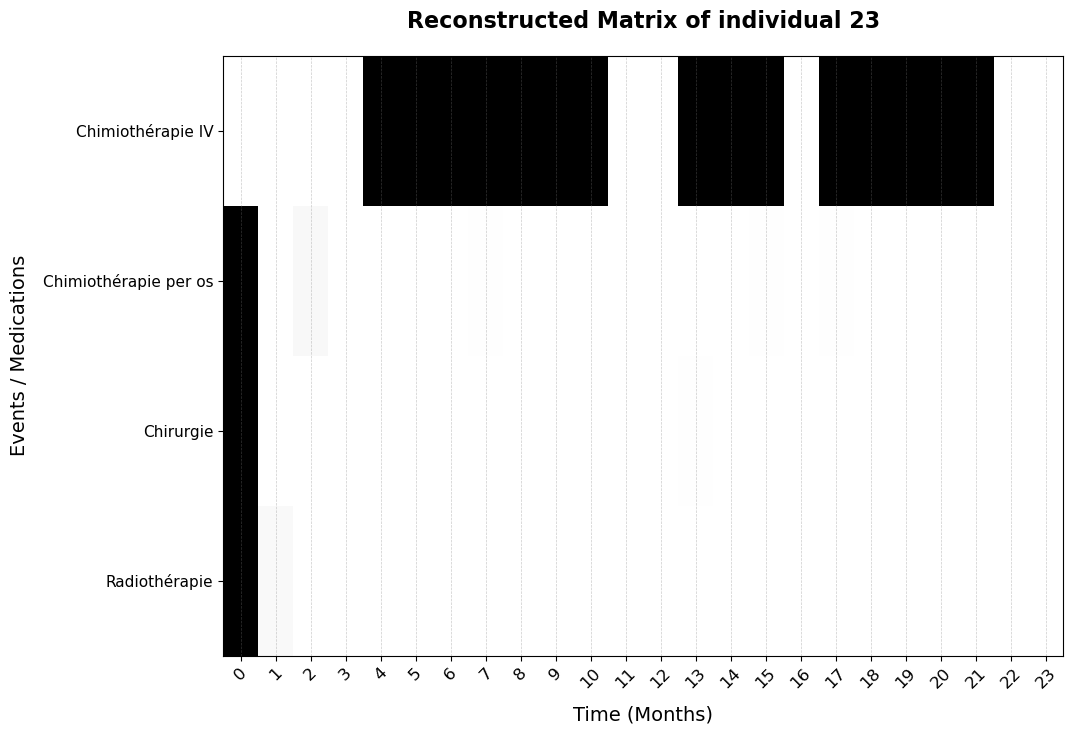

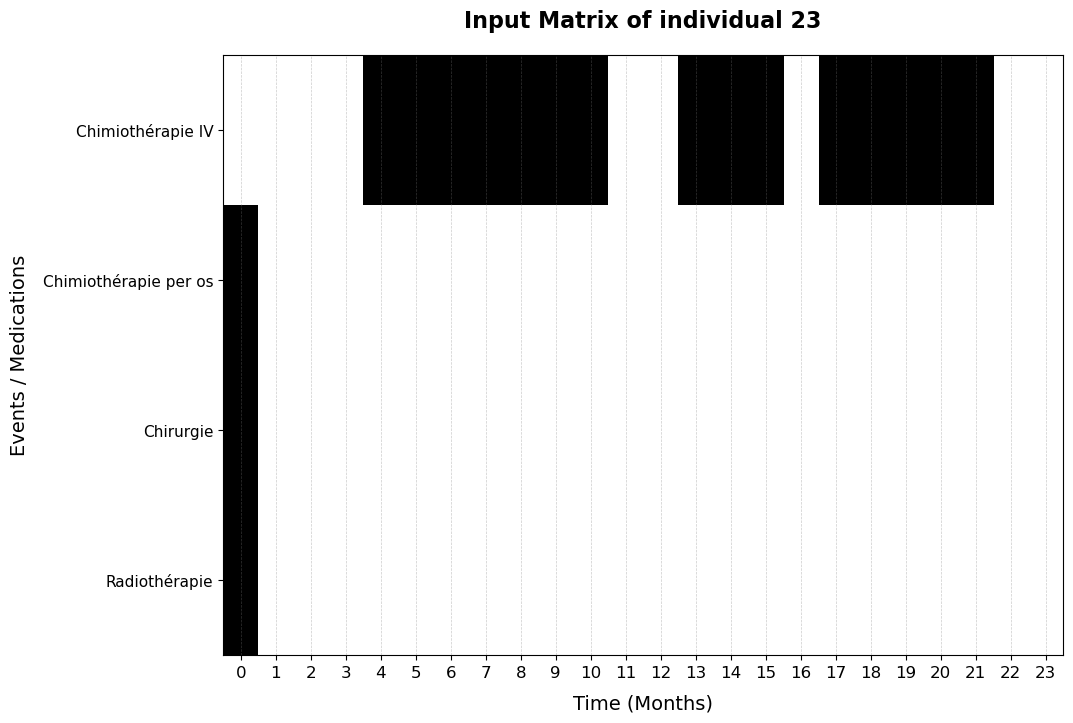

In [15]:
best_rank = 4
best_window = 3
best_reg_term_s = 0.7
best_reg_term_ns = 0.9

tca.analyzer.fit_swotted_decomposition(
        tensor, rank=best_rank, time_window_length=best_window, 
        reg_term_ns=best_reg_term_ns, reg_term_s=best_reg_term_s, metric=metric, 
        learning_rate=learning_rate, n_epochs=n_epochs, fit_metric_every_n_epochs=0 
    )

tca.analyzer.get_decomposition_results(labels=noms_events, id=patient_index, time_unit='Months')

Epoch 250/250 - FIT metric: -9.7729

La matrice reconstruite est très proche de la matrice de base pour un rang égal à 3, une taille de fenêtre de 3 mois, et terme de sparsité de 0.1 et un terme de non-succession de 0.9.
C'est la configuration pour laquelle on a les plus petits loss au bout de 200 époques.

Decomposed into 1336 pathways with rank 4 and time window length 3
Success rate for the entire dataset: -2.4874


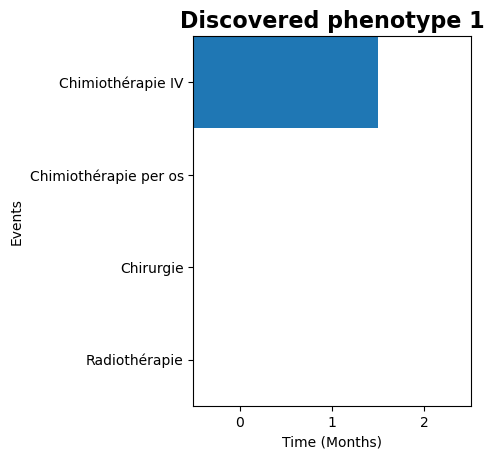

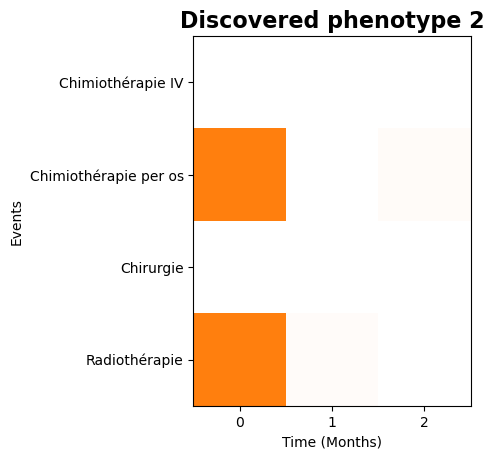

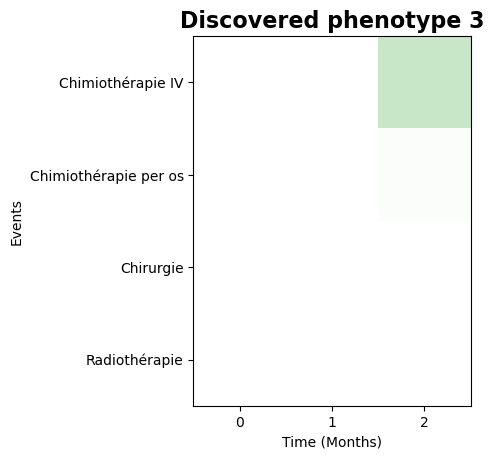

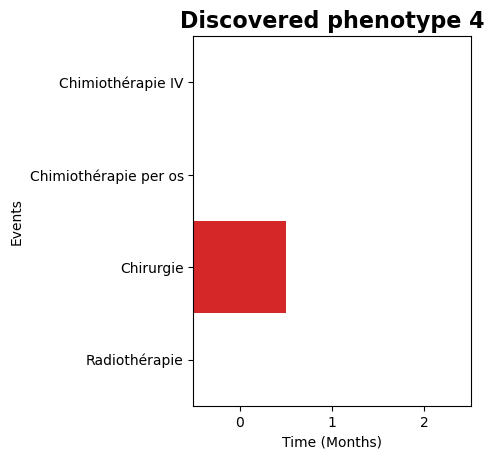

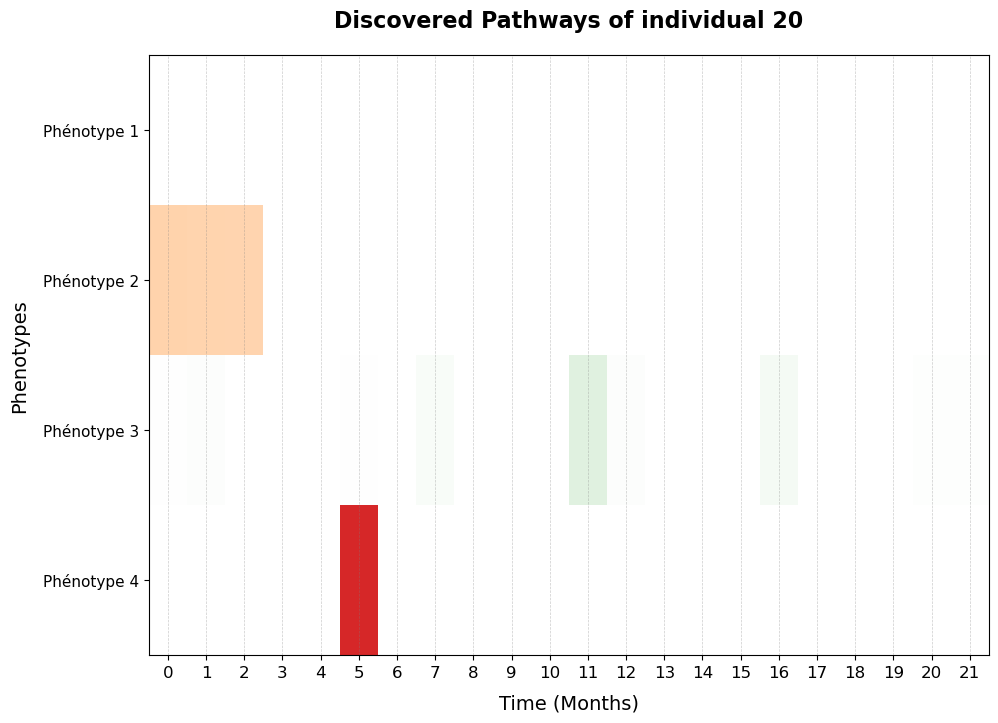

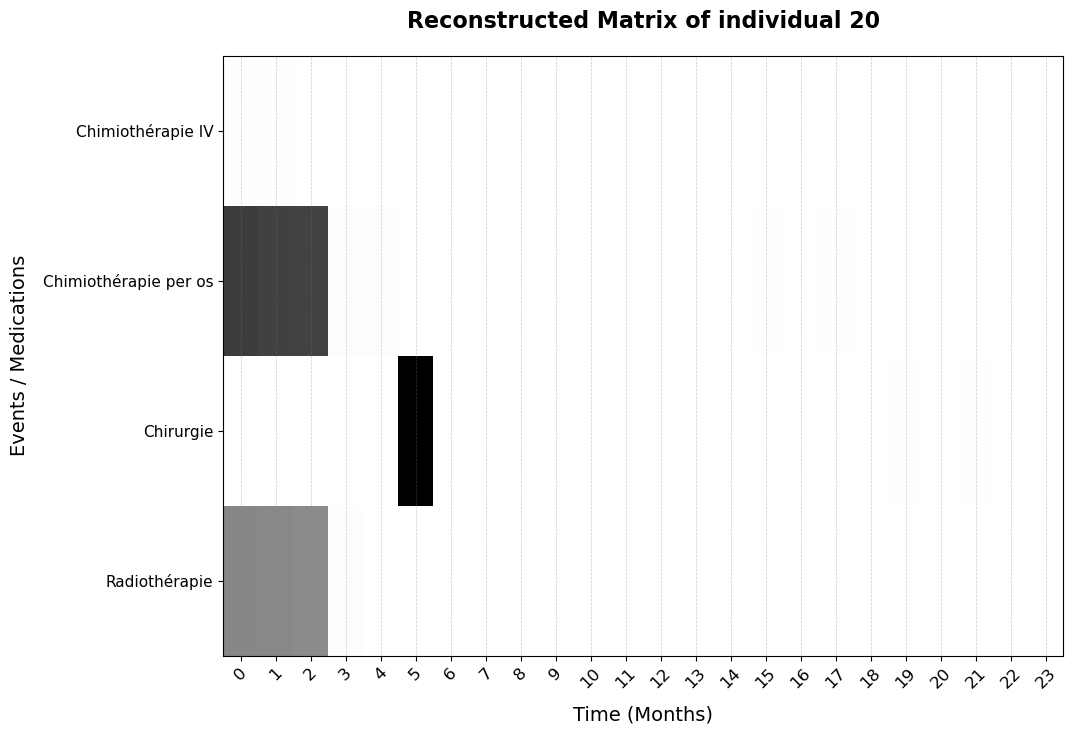

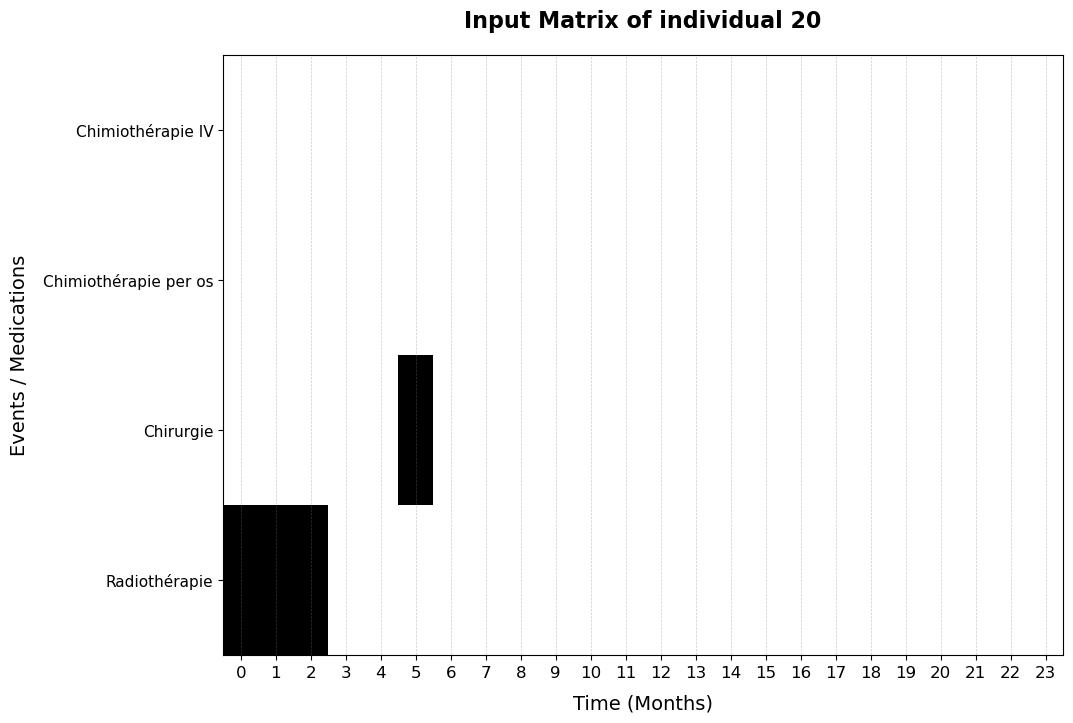

In [18]:
patient_index0 = int(patients_with_all_events[8])
tca.analyzer.get_decomposition_results(labels=noms_events, id=20, time_unit='Months')

* Phénotype 1 : Radiothérapie et la Chimiothérapie per os combinée sur le même mois.

* Phénotype 2 : Chirurgie sur 1 mois

* Phénotype 3 : Chimiothérapie IV sur 2 mois.

Success rate tjrs négatif ?

## 5. Clustering

### 5.1. Intensités des phénotypes :

In [19]:
from sklearn.preprocessing import MinMaxScaler
ph_intensity = tca.analyzer.to_phenotype_intensity(scaler=MinMaxScaler())
print("Shape intensites:", ph_intensity.shape)
ph_intensity.head()

Shape intensites: (1336, 5)


,Phenotype_1,Phenotype_2,Phenotype_3,Phenotype_4,ID_PATIENT
0,0.332292,0.000565,0.169164,0.323875,1
1,0.316361,0.001589,0.135260,0.337052,2
2,0.600809,0.455232,0.626562,0.002330,3
3,0.586015,0.006655,0.204751,0.336826,4
4,0.326499,0.003173,0.226228,0.335238,5


### 5.2. Clustering à partir des intensités :

INFO:root:Calculating distance matrix using metric: euclidean...
INFO:root:Time taken for computation: 0.01 seconds
INFO:root:Computing the linkage matrix using method: ward...
c:\Users\imen.miloudi\OneDrive - Aix-Marseille Université\Documents\stage\TrajectoryClusteringAnalysis\src\trajectoryclusteringanalysis\unidimensional\clustering.py:238: ClusterWarning: The symmetric non-negative hollow observation matrix looks suspiciously like an uncondensed distance matrix
  linkage_matrix = linkage(condensed_distance_matrix, method=method, optimal_ordering=optimal_ordering)
INFO:root:Linkage matrix computed successfully


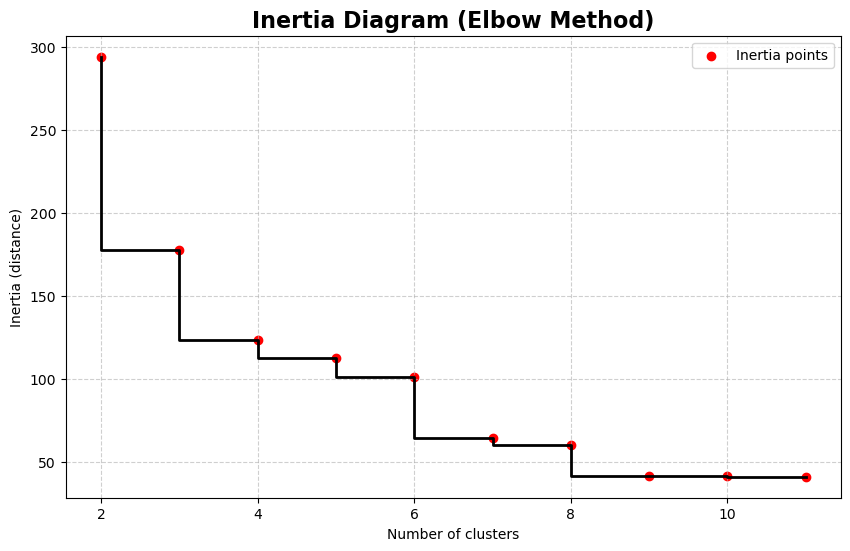

In [20]:
distance_matrix = tca.compute_distance_matrix(data=ph_intensity, metric='euclidean')
linkage_matrix = tca.hierarchical_clustering(distance_matrix)
tca.plot_inertia(linkage_matrix)

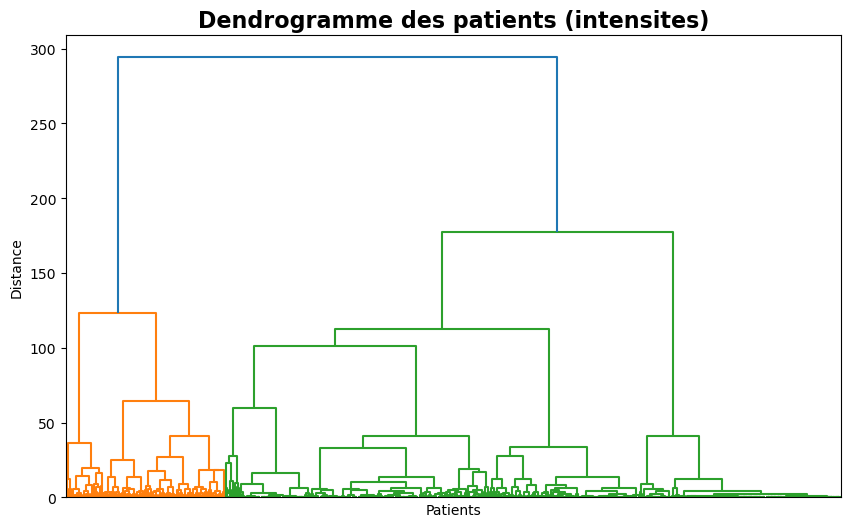

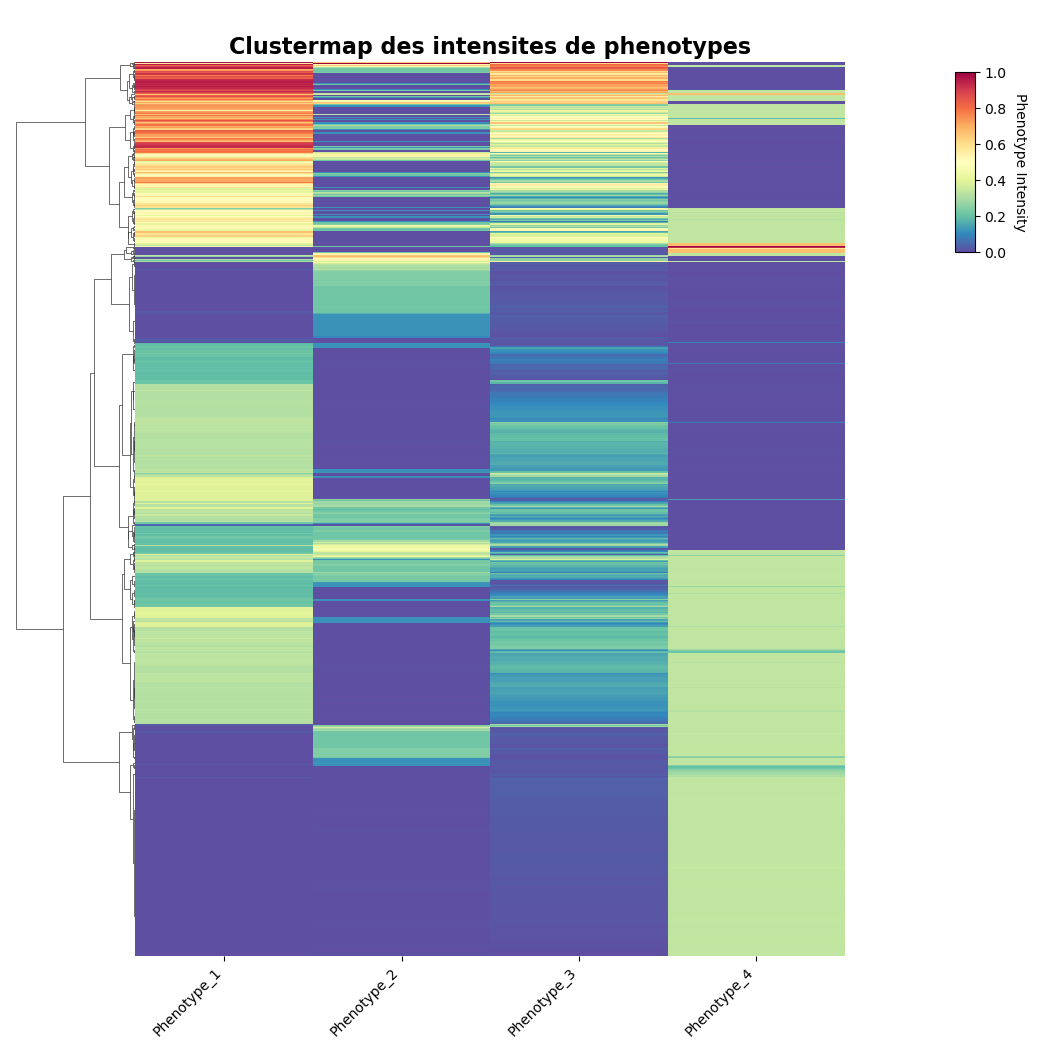

Effectifs par cluster:
1     63
2    212
3    715
4    346
Name: count, dtype: int64


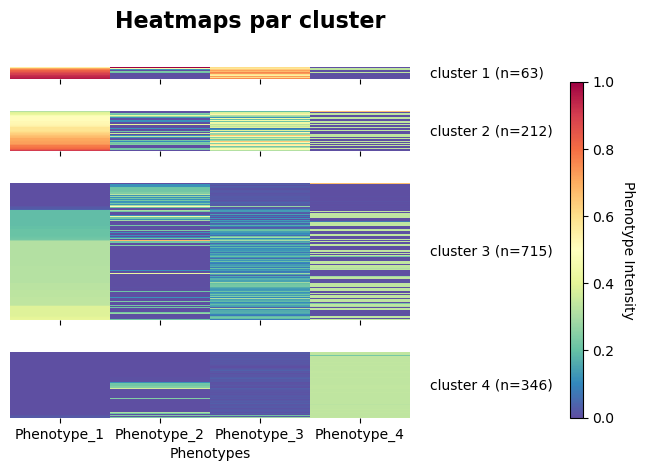

In [21]:
# Visualisations standard du package
tca.plot_dendrogram(linkage_matrix, title='Dendrogramme des patients (intensites)')
tca.plot_clustermap(ph_intensity, linkage_matrix, title='Clustermap des intensites de phenotypes')

clusters = tca.assign_clusters(linkage_matrix, num_clusters=4)
print("Effectifs par cluster:")
print(pd.Series(clusters).value_counts().sort_index())

tca.plot_cluster_heatmaps(ph_intensity, clusters, sorted=True, title='Heatmaps par cluster')

Pour chaque cluster, on peut regarder la durée totale moyenne des traitements.

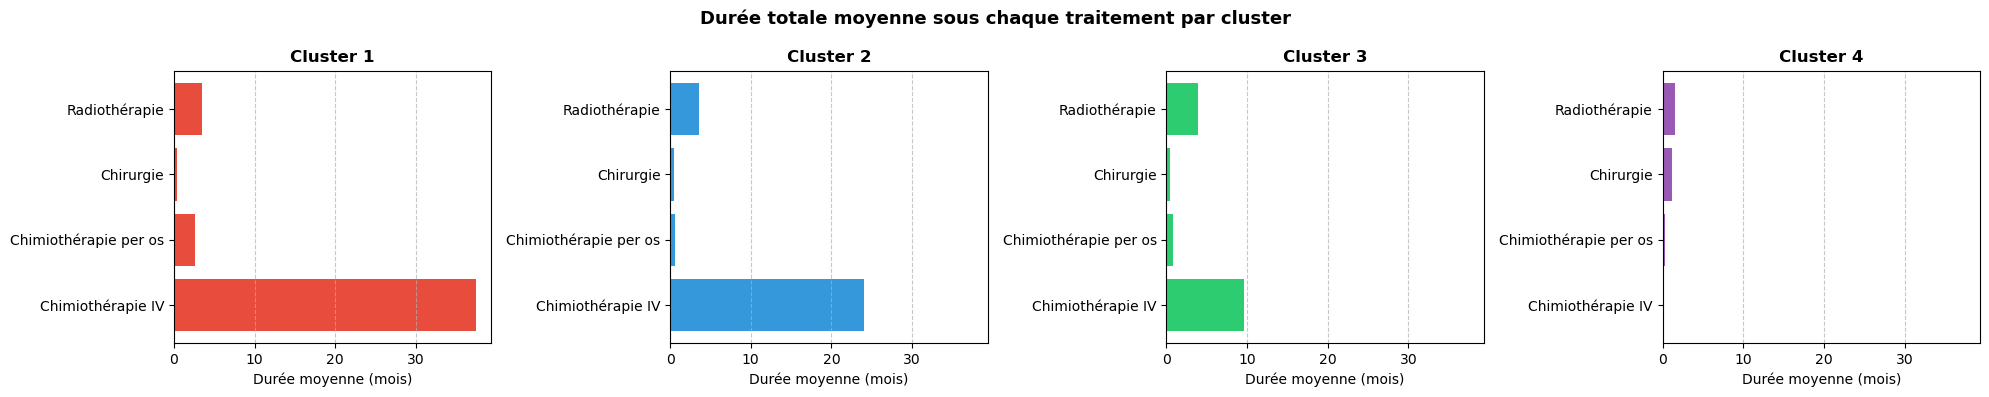

In [22]:
# Durée totale sous chaque traitement (barplot)
duree_trait = timed_event_structure.copy()
duree_trait['Traitement'] = duree_trait['Event'].map(dict(enumerate(noms_events)))
duree_pivot = duree_trait.groupby(['ID_PATIENT', 'Traitement'])['Time'].count().unstack(fill_value=0)

fig, axes = plt.subplots(1, len(set(clusters)), figsize=(5*len(set(clusters)), 4), squeeze=False, sharex=True)
colors = ['#e74c3c', '#3498db', '#2ecc71', '#9b59b6']
for ax, c in zip(axes[0], sorted(set(clusters))):
    ids = ph_intensity[np.array(clusters) == c]['ID_PATIENT']
    cluster_data = duree_pivot.loc[duree_pivot.index.isin(ids)].mean()
    ax.barh(cluster_data.index, cluster_data.values, color=colors[c-1])
    ax.set_title(f"Cluster {c}", fontweight='bold')
    ax.set_xlabel("Durée moyenne (mois)")
    ax.grid(axis='x', linestyle='--', alpha=0.7)
fig.suptitle("Durée totale moyenne sous chaque traitement par cluster", fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

In [23]:
def plot_reconstructed_vs_original(tca, patient_id, noms_events=None, figsize=(14, 8)):
    """
    Superpose la trajectoire réelle et la trajectoire reconstruite
    """
    if noms_events is None:
        noms_events = tca.analyzer.data[tca.analyzer.event_col].unique().tolist()
        
    labels = tca.analyzer.data[tca.analyzer.event_col].unique().tolist()
    
    # Extraction des matrices
    matrice_orig = tca.analyzer.get_tensor()[patient_id - 1].detach().cpu().numpy()
    matrice_recon = tca.analyzer.compute_reconstruction()[patient_id - 1].detach().cpu().numpy()

    # Affichage des résultats de la décomposition SWoTTeD
    tca.analyzer.get_decomposition_results(labels=noms_events, id=patient_id, time_unit='Days')

    # Binarisation pour les événements réels
    orig_bin = matrice_orig > 0
    seuil = 0.2
    recon_bin = matrice_recon > seuil

    matrice_recon[matrice_recon < 0.01] = 0.0

    # Normalisation de l'intensité
    vmax = np.max(matrice_recon) if np.max(matrice_recon) > 0.1 else 1.0
    intensite = np.clip(matrice_recon / vmax, 0, 1)

    hauteur, largeur = matrice_orig.shape
    image_rgb = np.ones((hauteur, largeur, 3))

    # Cas A : SWoTTeD prédit un évènement qui n'existe pas (rouge variable selon l'intensité)
    masque_vide_original = ~orig_bin
    int_r = intensite[masque_vide_original]

    image_rgb[masque_vide_original, 0] = (1 - int_r) + 0.91 * int_r  # Canal Rouge
    image_rgb[masque_vide_original, 1] = (1 - int_r) + 0.30 * int_r  # Canal Vert
    image_rgb[masque_vide_original, 2] = (1 - int_r) + 0.24 * int_r  # Canal Bleu

    # Cas B : SWoTTeD prédit correctement un évènement réel (vert variable selon l'intensité)
    masque_orig = orig_bin
    int_g = intensite[masque_orig]

    r_pale, g_pale, b_pale = 0.66, 0.90, 0.81
    r_vif, g_vif, b_vif = 0.18, 0.80, 0.44

    image_rgb[masque_orig, 0] = r_pale * (1 - int_g) + r_vif * int_g
    image_rgb[masque_orig, 1] = g_pale * (1 - int_g) + g_vif * int_g
    image_rgb[masque_orig, 2] = b_pale * (1 - int_g) + b_vif * int_g

    # Cas C : Événements pas retrouvés (Bleu) (Uniquement si l'intensité est quasi-nulle (< 0.01))
    masque_bleu = orig_bin & (intensite < 0.01)
    image_rgb[masque_bleu] = [0.20, 0.60, 0.86]

    plt.figure(figsize=figsize)
    plt.imshow(image_rgb, aspect='auto')

    plt.yticks(ticks=np.arange(len(labels)), labels=noms_events, fontsize=10)
    plt.xticks(ticks=np.arange(0, largeur, 2), fontsize=10)
    plt.xlabel("Temps (Jours)", fontsize=12)
    plt.ylabel("Événements / Médicaments", fontsize=12)
    plt.title(f"Trajectoire réelle VS trajectoire reconstruite du Patient {patient_id}", pad=20, fontweight='bold', fontsize=14)

    legend_patches = [
        mpatches.Patch(color='#e74c3c', alpha=0.5, label='Faux positifs de SWoTTeD'),
        mpatches.Patch(color='#3498db', label='Faux négatifs de SWoTTeD'),
        mpatches.Patch(color='#2ecc71', label='Bonne reconstruction')
    ]
    plt.legend(handles=legend_patches, bbox_to_anchor=(1.05, 1), loc='upper left', borderaxespad=0.)
    plt.grid(axis='x', color='gray', linestyle='--', linewidth=0.5, alpha=0.4)

    plt.tight_layout()
    plt.show()

Decomposed into 1336 pathways with rank 4 and time window length 3
Success rate for the entire dataset: -2.4874


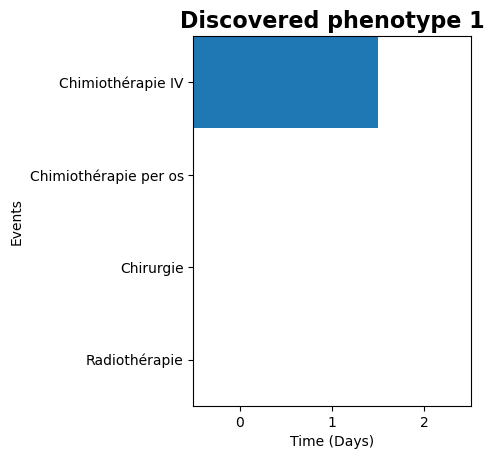

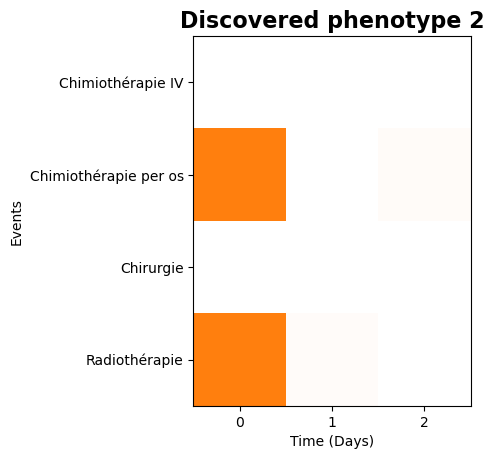

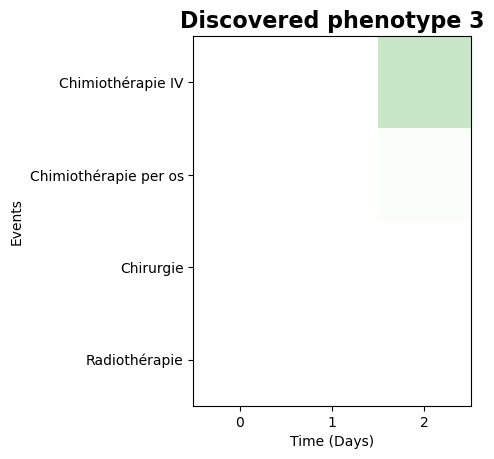

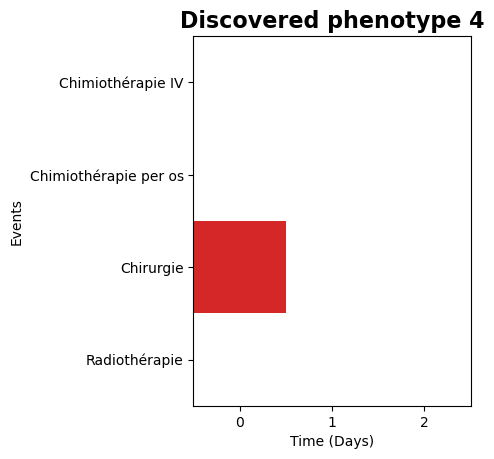

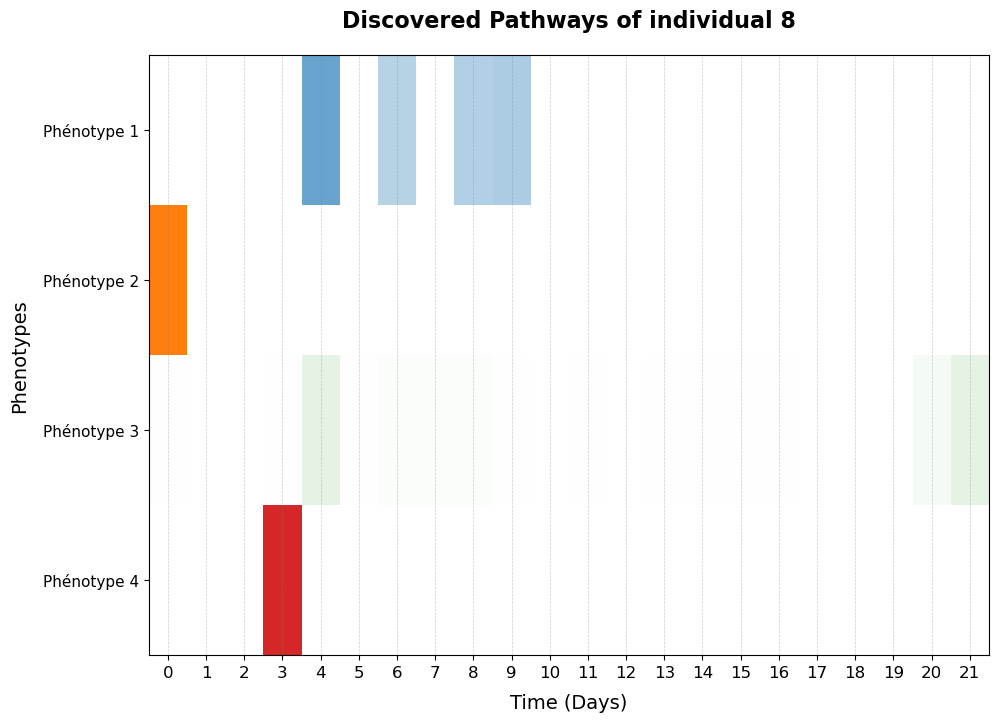

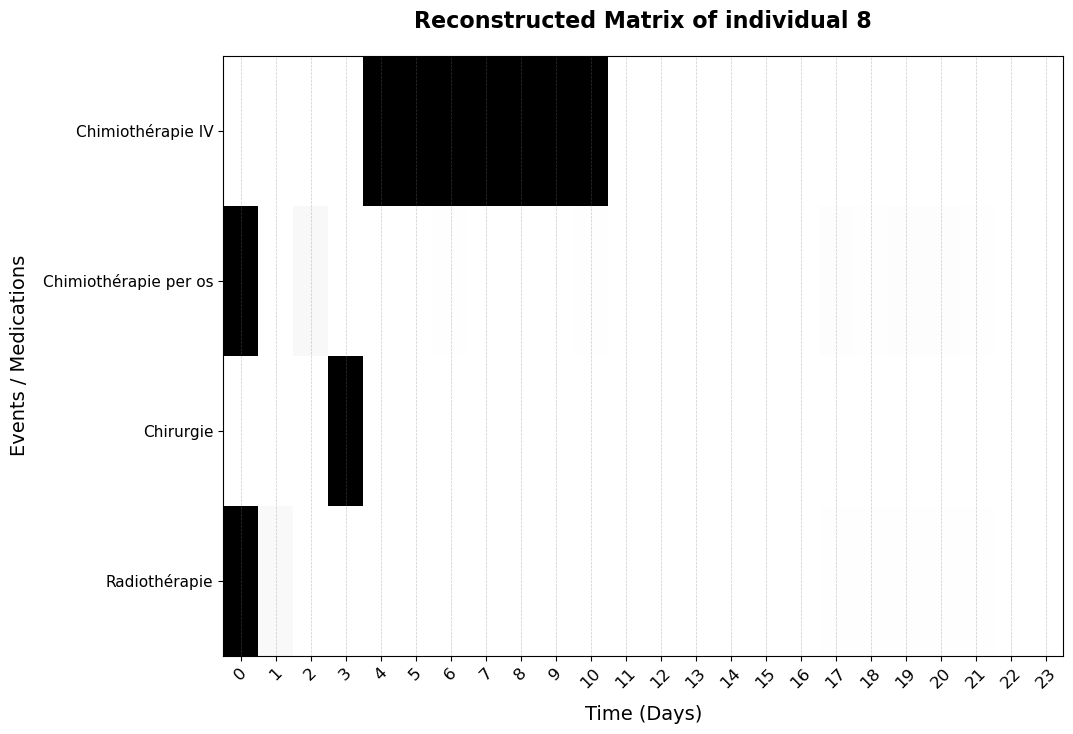

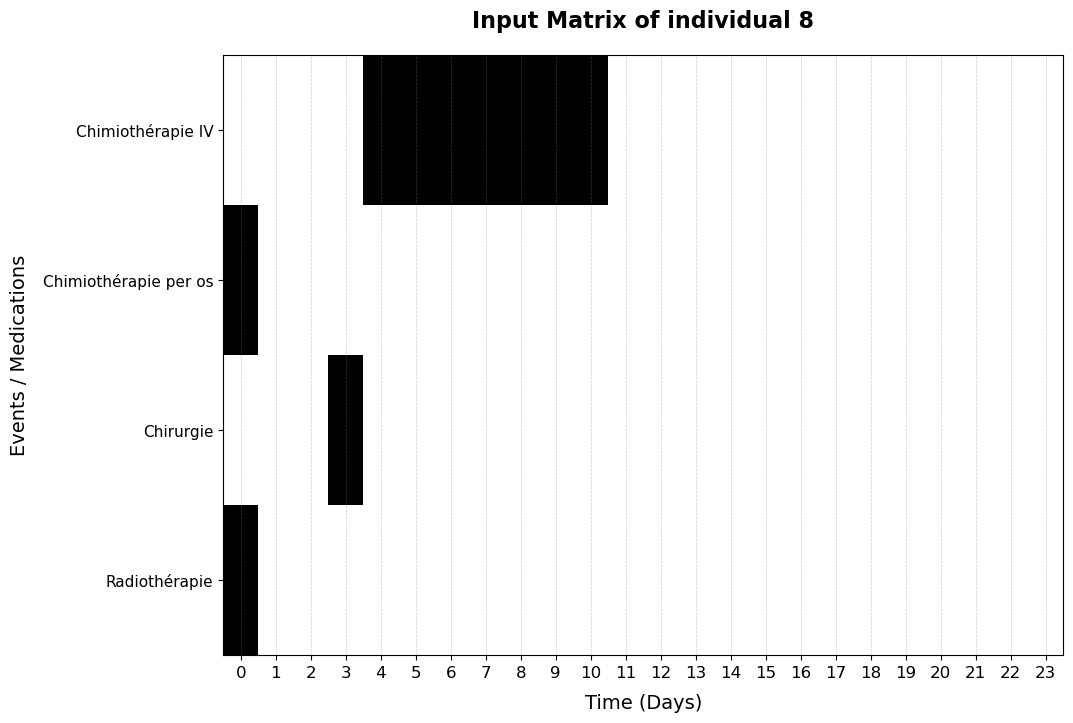

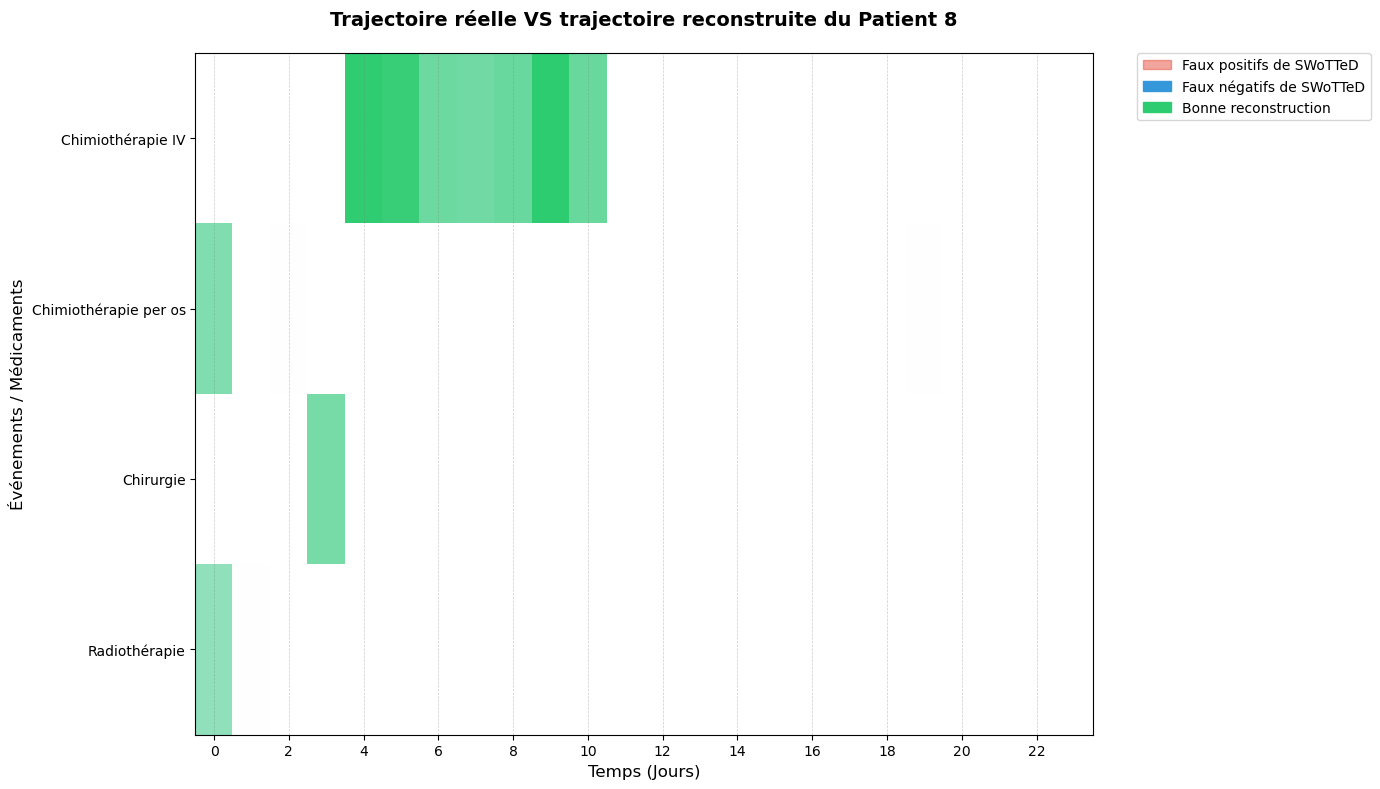

In [29]:
plot_reconstructed_vs_original(tca, patient_id=8, noms_events=noms_events)